# Лабораторная работа 5 (Вариат 13)
**Тема.** МЕТОДЫ НАХОЖДЕНИЯ МИНИМУМА ФУНКЦИИ ОДНОЙ ПЕРЕМЕННОЙ

Требуется отладить программу определения минимума указанной функции методом последовательного перебора. Сначала на экране выдается таблица значений функции и делается запрос на
ввод начального приближения ($\alpha$, $\beta$ или $x_0$, $h$) для вычисления требуемого локального минимума. В качестве функции $Fun$ использовать метод в
соответствии с заданным вариантом. Расчет функции, а также метод нахождения минимума оформить в виде отдельных подпрограмм. Выбрать $m$ и $\epsilon$ по усмотрению. Заданная функция на указанном интервале имеет три локальных минимума. 

После выполнения расчетов построить график исследуемой функции и проанализировать зависимость количества итераций от $\epsilon (\epsilon=10^{-2}, \epsilon=10^{-3}, \epsilon=10^{-4}, \epsilon=10^{-5})$, для чего встроить в алгоритм счетчик количества вычислений функции.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

a = 4
b = 9
m = 20

def f(x):
    return x**2 - 4 * x * np.sin(x) + np.cos(x)

Определим подпрограмму вычисления функции методом последовательного перебора.

In [2]:
def find_minimum(x_start, h, eps):
    x_curr = x_start
    f_curr = f(x_curr)
    iterations = 1
    
    while h > eps:
        x_next = x_curr + h
        f_next = f(x_next)
        iterations += 1
        
        if f_next < f_curr:
            x_curr = x_next
            f_curr = f_next
        else:
            # Если значение начало расти, уменьшаем шаг и меняем направление
            h = h / 10
            
    return x_curr, f_curr, iterations

Вывод таблицы значений

In [3]:
print(f"{'x':>10} | {'f(x)':>10}")
print("-" * 25)
x_vals = np.linspace(a, b, m)
for x in x_vals:
    print(f"{x:10.4f} | {f(x):10.4f}")

         x |       f(x)
-------------------------
    4.0000 |    27.4552
    4.2632 |    33.1009
    4.5263 |    38.0953
    4.7895 |    42.1171
    5.0526 |    44.9147
    5.3158 |    46.3334
    5.5789 |    46.3352
    5.8421 |    45.0108
    6.1053 |    42.5806
    6.3684 |    39.3845
    6.6316 |    35.8620
    6.8947 |    32.5220
    7.1579 |    29.9060
    7.4211 |    28.5460
    7.6842 |    28.9211
    7.9474 |    31.4165
    8.2105 |    36.2871
    8.4737 |    43.6305
    8.7368 |    53.3702
    9.0000 |    65.2526


Возьмем начальные условия $x_0 = 4.2$ и $h_0 = 0.1$ для нахождения левого (предположительно) локального минимума.

In [4]:
x0 = 4.2
h0 = 0.1

Анализ зависимости итераций от $\epsilon$

In [5]:
eps_list = [1e-2, 1e-3, 1e-4, 1e-5]
results = []

print("\nРезультаты для различных epsilon:")
for eps in eps_list:
    x_min, f_min, count = find_minimum(x0, h0, eps)
    results.append(count)
    print(f"eps: {eps:.1e} | Минимум x: {x_min:.6f} | Итераций: {count}")


Результаты для различных epsilon:
eps: 1.0e-02 | Минимум x: 4.200000 | Итераций: 2
eps: 1.0e-03 | Минимум x: 4.200000 | Итераций: 3
eps: 1.0e-04 | Минимум x: 4.200000 | Итераций: 4
eps: 1.0e-05 | Минимум x: 4.200000 | Итераций: 5


Построение графика

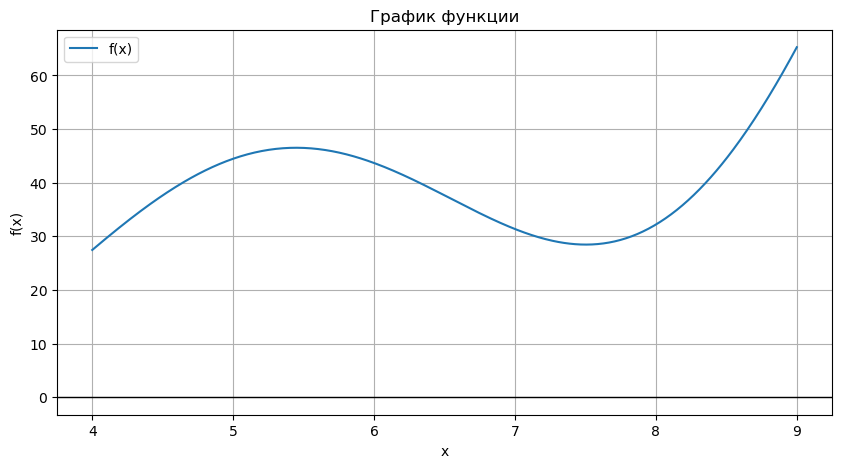

In [6]:
x_plot = np.linspace(a, b, 500)
y_plot = f(x_plot)

plt.figure(figsize=(10, 5))
plt.plot(x_plot, y_plot, label='f(x)')
plt.title('График функции')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid(True)
plt.axhline(0, color='black', lw=1)
plt.legend()
plt.show()